In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = os.path.join(os.getcwd(), "data")

In [37]:
data = {}
for filename in os.listdir(DATA_DIR):
    if filename.endswith(".csv"):
        filepath = os.path.join(DATA_DIR, filename)
        response = pd.read_csv(filepath, index_col="Date", parse_dates=True)
        data[filename] = response

for filename, df in data.items():
    print(data[filename].head())
    print(data[filename].shape)

                Close       High        Low       Open   Volume
Date                                                           
2021-03-02  23.881668  23.916253  23.700090  23.760616  2833200
2021-03-03  23.743322  23.907607  23.674150  23.864375  3187600
2021-03-04  23.535807  23.812496  23.319644  23.708738  6290900
2021-03-05  23.890314  23.933548  23.432050  23.700091  6810600
2021-03-08  23.985422  24.184291  23.864372  23.916250  3941500
(1255, 5)
                Close       High        Low       Open  Volume
Date                                                          
2021-03-02  32.468483  32.520779  32.250572  32.329022  207845
2021-03-03  32.302876  32.485918  32.189564  32.477202  221264
2021-03-04  31.971642  32.346444  31.675285  32.250564  427022
2021-03-05  32.433620  32.477201  31.762461  32.206994  354460
2021-03-08  32.581783  32.817125  32.398741  32.494622  481792
(1255, 5)
                Close       High        Low       Open   Volume
Date                       

{'XIU_TO.csv'}
                Close       High        Low       Open   Volume  rsi_14  \
Date                                                                      
2021-03-02  23.881668  23.916253  23.700090  23.760616  2833200     NaN   
2021-03-03  23.743322  23.907607  23.674150  23.864375  3187600     NaN   
2021-03-04  23.535807  23.812496  23.319644  23.708738  6290900     NaN   
2021-03-05  23.890314  23.933548  23.432050  23.700091  6810600     NaN   
2021-03-08  23.985422  24.184291  23.864372  23.916250  3941500     NaN   
2021-03-09  24.123775  24.314000  24.097837  24.141069  2979700     NaN   

            return_1day  return_5day  return_10day  return_20day      sma_5  \
Date                                                                          
2021-03-02          NaN          NaN           NaN           NaN        NaN   
2021-03-03    -0.005793          NaN           NaN           NaN        NaN   
2021-03-04    -0.008740          NaN           NaN           NaN    

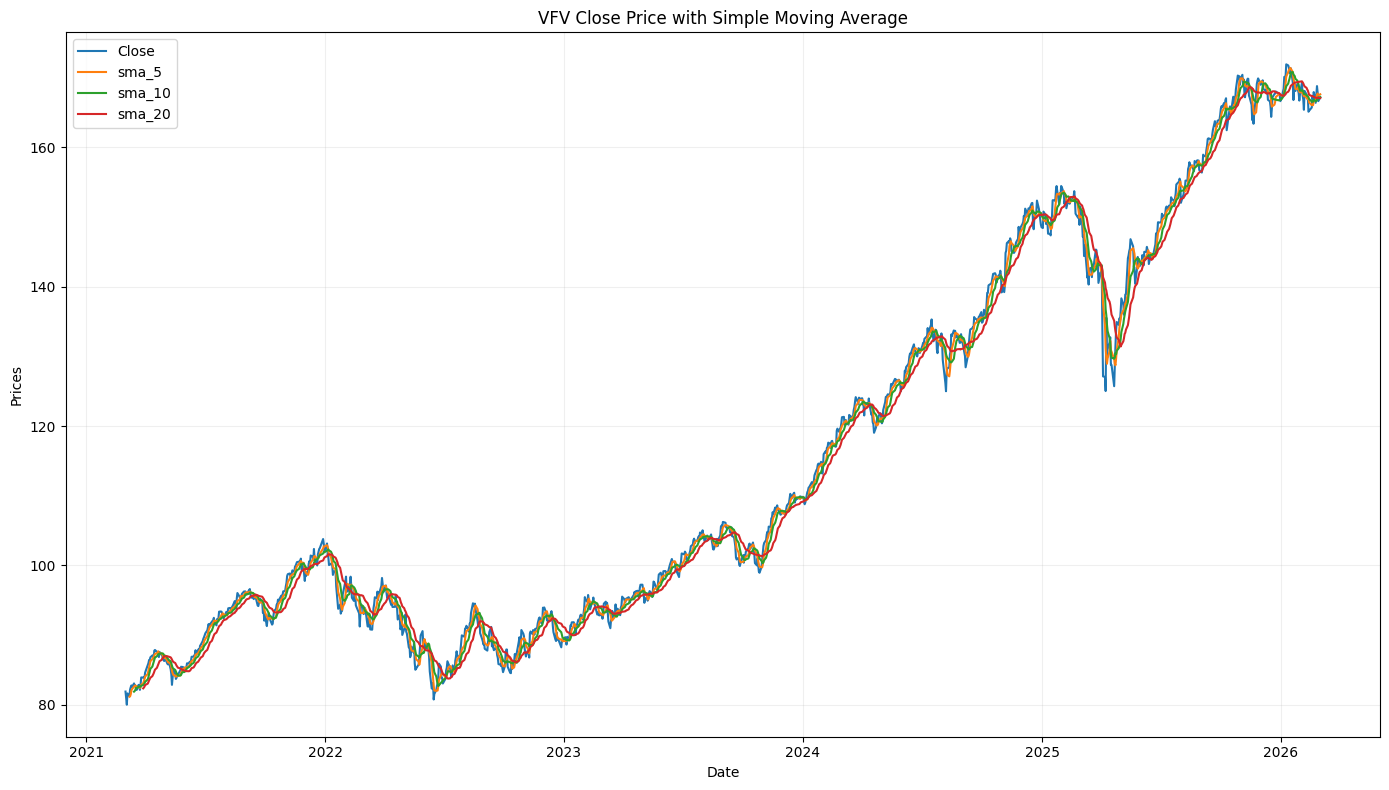

,Close,High,Low,Open,Volume,rsi_14,return_1day,return_5day,return_10day,return_20day,sma_5,close_ratio_amv_5,sma_10,close_ratio_amv_10,sma_20,close_ratio_amv_20
Date,,,,,,,,,,,,,,,,
2021-03-02,81.894852,82.847558,81.894852,82.847558,182400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-03,81.008171,82.423079,81.008171,82.423079,185600,NaN,-0.010827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-04,80.008324,81.244008,79.263138,80.904429,311900,NaN,-0.012343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-05,81.630745,81.725071,79.470652,81.036486,263500,NaN,0.020278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-03-08,81.206261,82.347626,81.206261,82.064641,232800,NaN,-0.005200,NaN,NaN,NaN,81.149670,1.000697,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,167.639999,167.850006,166.179993,166.699997,282100,50.652035,0.007573,0.011708,0.000358,-0.008517,167.212003,1.002560,166.632002,1.006049,167.065001,1.003442
2026-02-25,168.779999,168.919998,168.000000,168.000000,198100,56.237643,0.006800,0.009208,0.010719,0.003568,167.520001,1.007521,166.811002,1.011804,167.095001,1.010084
2026-02-26,167.839996,169.000000,167.000000,168.919998,339800,58.436210,-0.005569,0.005753,0.003708,0.000238,167.712000,1.000763,166.873001,1.005795,167.097001,1.004446


In [43]:
#Lagged Returns
for stock, dataframe in data.items():
    dataframe['return_1day'] = dataframe["Close"].pct_change(1)
    dataframe['return_5day'] = dataframe["Close"].pct_change(5)
    dataframe['return_10day'] = dataframe["Close"].pct_change(10)
    dataframe['return_20day'] = dataframe["Close"].pct_change(20)
    # print(f"--- {stock} ---")
    # print(dataframe[["Close", "return_1day", "return_5day", "return_10day", "return_20day"]].head(10))

#Simple Moving Average
for stock, dataframe in data.items():
    for day in [5, 10, 20]:
        simple_moving_average = f"sma_{day}"
        #we get the ratio of close and simple moving average to get the ratio so it normalizes our data 
        #in terms of the increase so $100 to $105 has the same impact as $3000 to $3005.
        close_ratio_amv = f"close_ratio_amv_{day}"
        dataframe[simple_moving_average] = dataframe["Close"].rolling(window=day).mean()
        dataframe[close_ratio_amv] = dataframe["Close"] / dataframe[simple_moving_average]
        print({stock})
        print(dataframe.head(6))
#VFV example
figure, axis = plt.subplots(figsize=(14, 8))
axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["Close"], label="Close")
for number in [5, 10, 20]:
    axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"][f"sma_{number}"], label=f"sma_{number}")
axis.set_title("VFV Close Price with Simple Moving Average")
axis.set_ylabel("Prices")
axis.set_xlabel("Date")
plt.tight_layout()
plt.legend()
axis.grid(True, alpha=0.2)
plt.show()
data["VFV_TO.csv"]

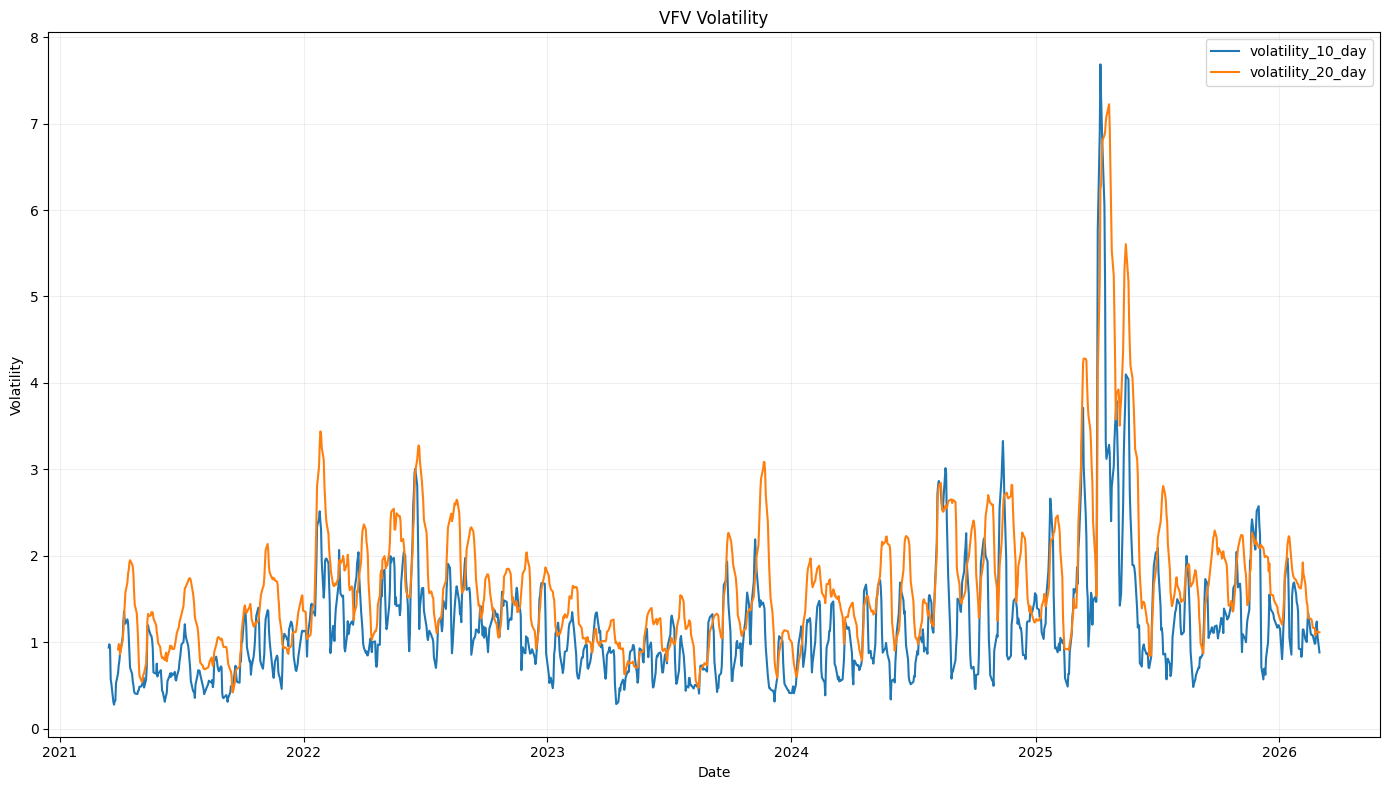

In [44]:
for stock, dataframe in data.items():
    dataframe["volatility_10_day"] = dataframe["Close"].rolling(window=10).std()
    dataframe["volatility_20_day"] = dataframe["Close"].rolling(window=20).std()
    
figure, axis = plt.subplots(figsize=(14, 8))
for number in [10, 20]:
    axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"][f"volatility_{number}_day"], label=f"volatility_{number}_day")
axis.grid(alpha=0.2)
axis.set_title("VFV Volatility")
axis.set_ylabel("Volatility")
axis.set_xlabel("Date")
plt.tight_layout()
plt.legend()
plt.show()


    
    

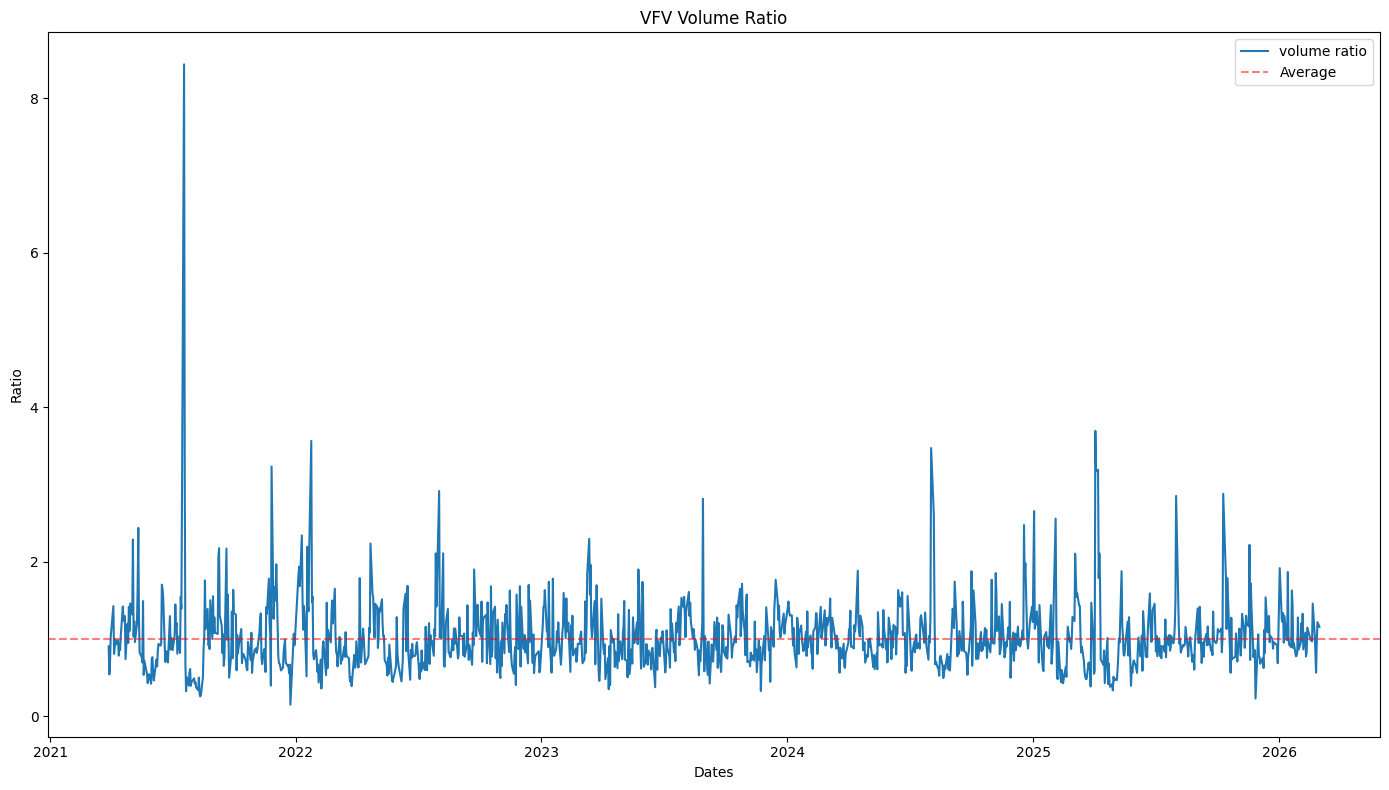

In [ ]:
#Volume

for stock, dataframe in data.items():
    dataframe["volume_1day"] = dataframe["Volume"].pct_change(1)
    dataframe["volume_20_sma"] = dataframe["Volume"].rolling(window=20).mean()
    dataframe["volume_normalize_ratio"] = dataframe["Volume"] / dataframe["volume_20_sma"]

figure, axis = plt.subplots(figsize=(14, 8))
axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["volume_normalize_ratio"], label="volume ratio")
axis.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="Average")
axis.set_xlabel("Dates")
axis.set_ylabel("Ratio")
axis.set_title("VFV Volume Ratio")
axis.grid(alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

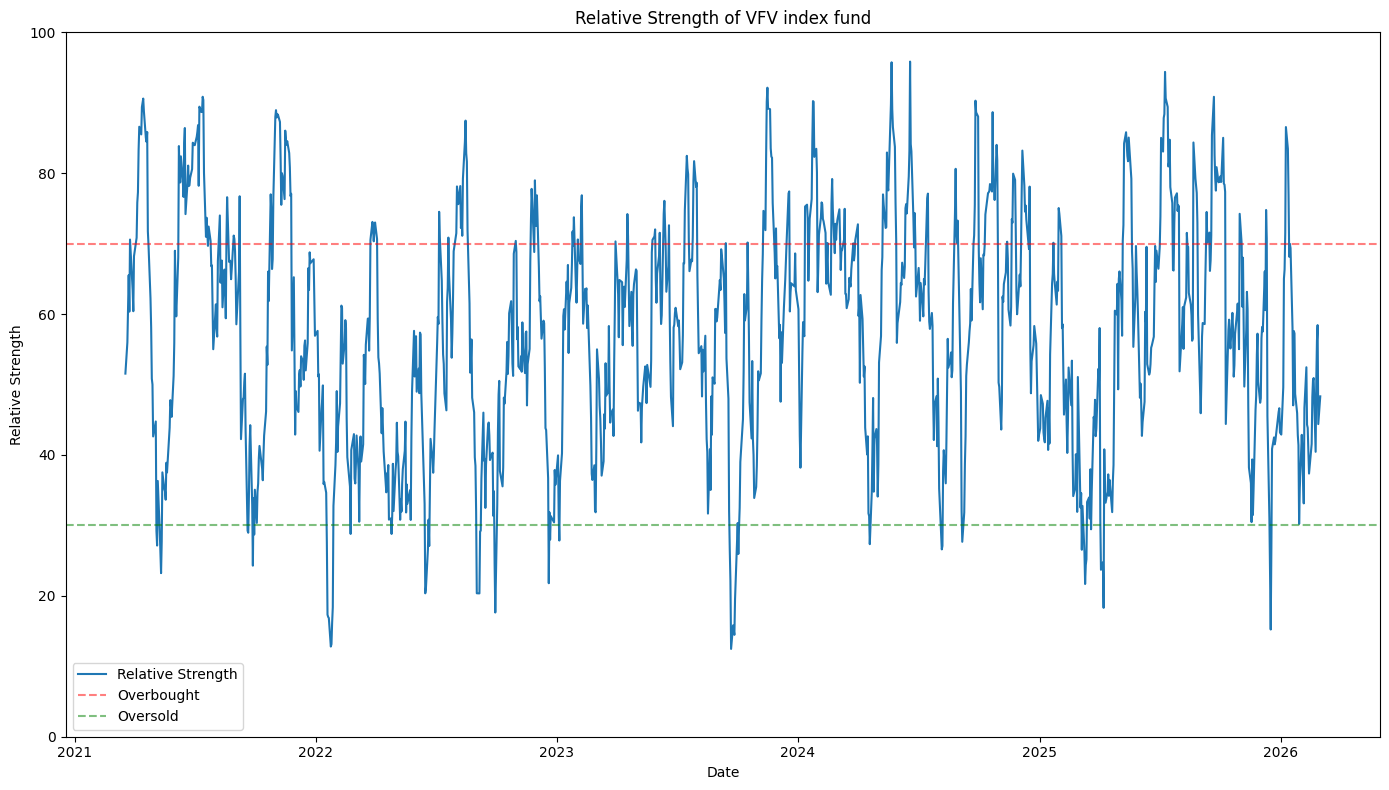

,Close,High,Low,Open,Volume,rsi_14,return_1day,return_5day,return_10day,return_20day,...,close_ratio_amv_5,sma_10,close_ratio_amv_10,sma_20,close_ratio_amv_20,volatility_10_day,volatility_20_day,volume_1day,volume_20_sma,volume_normalize_ratio
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-06,168.089996,168.309998,165.500000,165.500000,305500,46.673933,0.016386,0.002684,0.000119,-0.022164,...,1.004026,167.648000,1.002636,168.738999,0.996154,1.146945,1.796794,-0.354668,353275.0,0.864765
2026-02-09,167.580002,168.100006,166.460007,166.679993,387400,52.450991,-0.003034,-0.009984,-0.008872,-0.024279,...,1.003005,167.498000,1.000490,168.530499,0.994360,1.031092,1.666206,0.268085,358020.0,1.082062
2026-02-10,166.990005,167.800003,166.880005,167.460007,275800,44.296222,-0.003521,-0.002747,-0.007076,-0.026013,...,1.000024,167.379001,0.997676,168.307500,0.992172,1.012131,1.549256,-0.288074,357030.0,0.772484
2026-02-11,167.220001,168.520004,166.929993,168.220001,286100,43.846657,0.001377,0.001977,-0.003457,-0.020100,...,1.001006,167.321001,0.999396,168.136000,0.994552,1.001892,1.463788,0.037346,342665.0,0.834926
2026-02-12,165.100006,167.960007,164.910004,167.610001,397800,40.724531,-0.012678,-0.001693,-0.009598,-0.035631,...,0.988646,167.161002,0.987671,167.831001,0.983728,1.216793,1.426802,0.390423,346850.0,1.146893
2026-02-13,165.250000,166.169998,164.380005,165.190002,392600,37.359712,0.000909,-0.016896,-0.014257,-0.035543,...,0.992922,166.922002,0.989983,167.526501,0.986411,1.340669,1.280905,-0.013072,352265.0,1.114502
2026-02-17,165.699997,166.289993,164.679993,165.429993,350100,41.564621,0.002723,-0.011219,-0.021091,-0.021322,...,0.997880,166.565001,0.994807,167.346001,0.990164,1.099607,1.270666,-0.108253,356190.0,0.982902
2026-02-18,167.240005,167.789993,166.289993,166.580002,344200,48.234558,0.009294,0.001497,-0.001254,0.002758,...,1.006851,166.544002,1.004179,167.369001,0.999229,1.082704,1.264028,-0.016852,347570.0,0.990304
2026-02-19,166.880005,167.330002,166.220001,166.779999,329100,50.595265,-0.002153,-0.002033,-0.000060,-0.010788,...,1.005095,166.543002,1.002024,167.278001,0.997621,1.082353,1.228167,-0.043870,340200.0,0.967372


In [ ]:
#relative strength
def relative_strength(data, series=14):
    close_difference = data.diff()
    gain = close_difference.where(close_difference > 0, 0.0)
    loss = -close_difference.where(close_difference < 0, 0.0)
    avg_gain = gain.rolling(window=series).mean()
    avg_loss = loss.rolling(window=series).mean()
    average_score = avg_gain / avg_loss
    return 100 - (100 / (1 + average_score))

for stock, dataframe in data.items():
    dataframe["rsi_14"] = relative_strength(dataframe["Close"])

figure, axis = plt.subplots(figsize=(14, 8))
axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["rsi_14"], label="Relative Strength")
axis.set_ylim(0, 100)
axis.axhline(y=70, color="red", linestyle="--", alpha=0.5, label="Overbought")
axis.axhline(y=30, color="green", linestyle="--", alpha=0.5, label="Oversold")
axis.set_title("Relative Strength of VFV index fund")
axis.set_ylabel("Relative Strength")
axis.set_xlabel("Date")
axis.grid(alpha=0.3)
plt.tight_layout()
axis.legend()
plt.show()


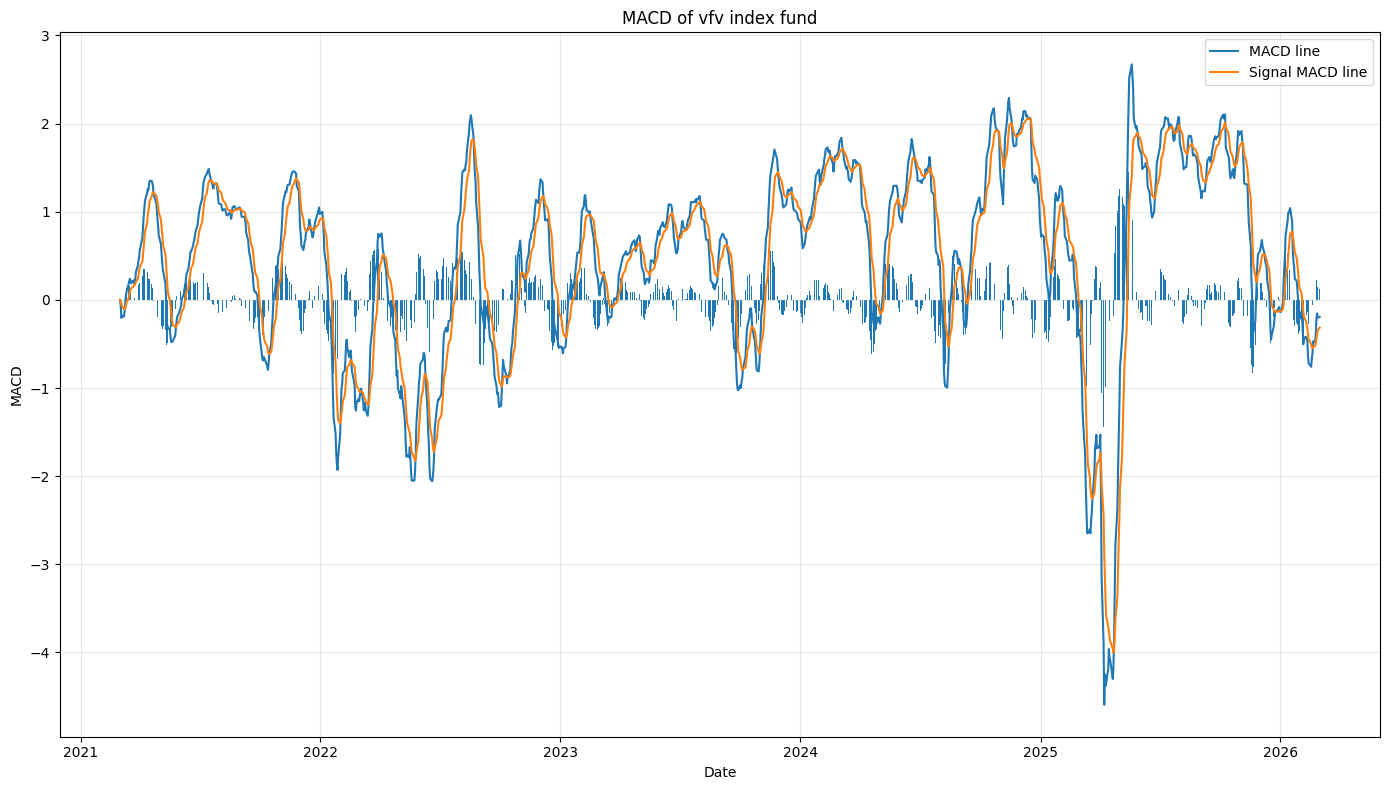

In [55]:
#Caclulating the MACD
for stock, dataframe in data.items():
    ema_12 = dataframe["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = dataframe["Close"].ewm(span=26, adjust=False).mean()
    dataframe["macd_line"] = ema_12 - ema_26
    dataframe["macd_signal_line"] = dataframe["macd_line"].ewm(span=9, adjust=False).mean()
    dataframe["mcad_histogram"] = dataframe["macd_line"] - dataframe["macd_signal_line"]

figure, axis = plt.subplots(figsize=(14, 8))
axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["macd_line"], label="MACD line")
axis.plot(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["macd_signal_line"], label="Signal MACD line")
axis.bar(data["VFV_TO.csv"].index, data["VFV_TO.csv"]["mcad_histogram"])
axis.set_title("MACD of vfv index fund")
axis.set_ylabel("MACD")
axis.set_xlabel("Date")
axis.legend()
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

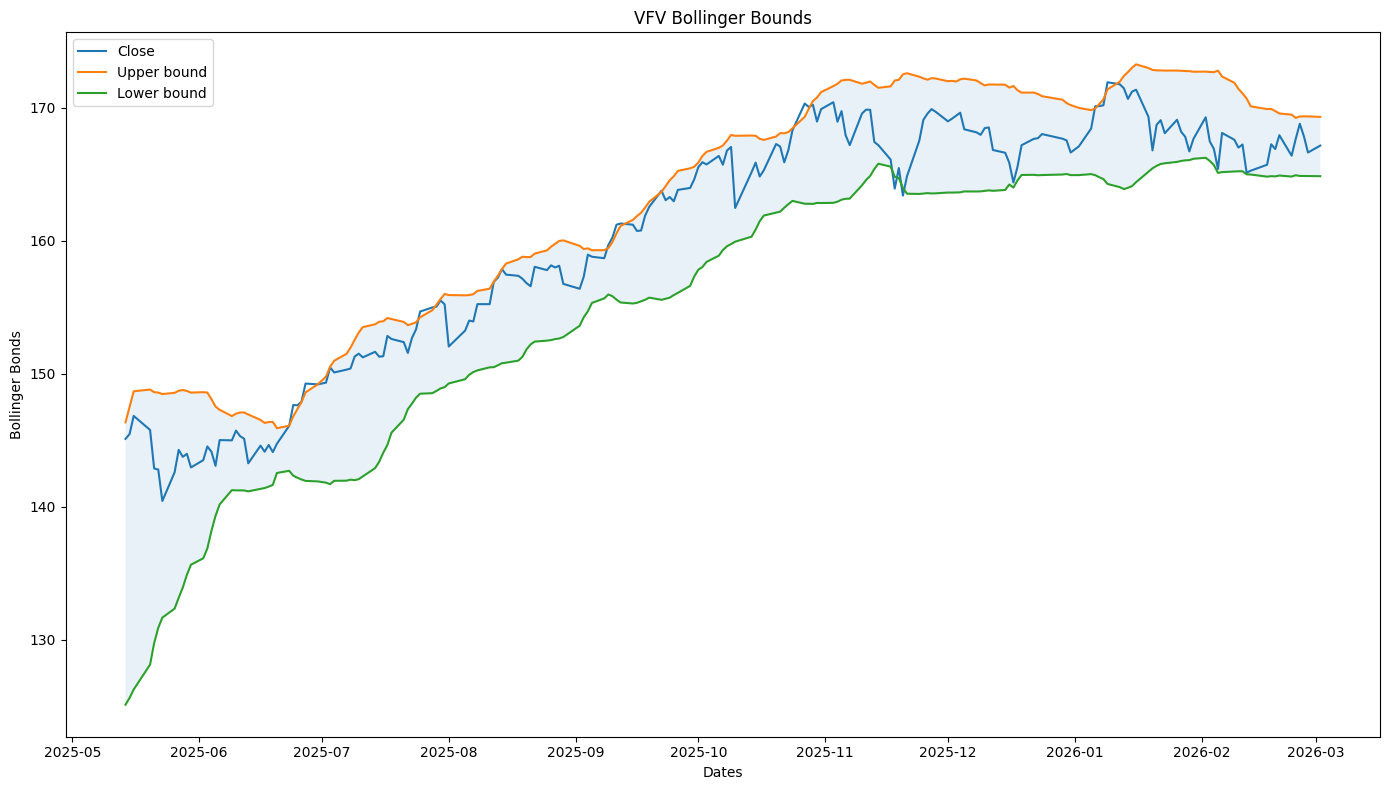

In [ ]:
#Bollinger Bands
for stock, dataframe in data.items():
    sma_20_days = dataframe["Close"].rolling(window=20).mean()
    std_20_days = dataframe["Close"].rolling(window=20).std()
    dataframe["bb_upper_bound"] = sma_20_days + (2 * std_20_days)
    dataframe["bb_lower_bound"] = sma_20_days - (2 * std_20_days)
    dataframe["bb_width"] = (dataframe["bb_upper_bound"] - dataframe["bb_lower_bound"]) / sma_20_days
    dataframe["bb_pct_b"] = (dataframe["Close"] - dataframe["bb_lower_bound"]) / (dataframe["bb_upper_bound"] - dataframe["bb_lower_bound"])
    
recent = data["VFV_TO.csv"].iloc[-200:]
figure, axis = plt.subplots(figsize=(14, 8))
axis.plot(recent.index, recent["Close"], label="Close")
axis.plot(recent.index, recent["bb_upper_bound"], label="Upper bound")
axis.plot(recent.index, recent["bb_lower_bound"], label="Lower bound")
axis.fill_between(recent.index, recent["bb_lower_bound"], recent["bb_upper_bound"], alpha=0.1)
axis.set_xlabel("Dates")
axis.set_ylabel("Bollinger Bonds")
axis.set_title("VFV Bollinger Bounds")


axis.legend()
plt.tight_layout()
plt.show()

In [ ]:
DAYS = 5
for stock, dataframe in data.items():
    dataframe["future_return"] = dataframe["Close"].shift(-DAYS) / dataframe["Close"] - 1
    dataframe["target"] = (dataframe["future_return"] > 0).astype(int)
 
print(f"Target distribution:")
print(data["VFV_TO.csv"]["target"].value_counts())
print(f"\nClass balance: {df['target'].mean():.2%} positive (price goes up)")

columns_to_view = [
    'close_ratio_amv_20', 'volatility_10_day', 'volatility_20_day', 
    'volume_1day', 'volume_20_sma', 'volume_normalize_ratio', "Close", "target", "future_return"
]

print(data["VFV_TO.csv"][columns_to_view].tail(15).to_string(
    index=False,               
    justify='right',       
    float_format="{:.6f}".format  
))

Target distribution:
target
1    757
0    498
Name: count, dtype: int64

Class balance: 60.32% positive (price goes up)
 close_ratio_amv_20  volatility_10_day  volatility_20_day  volume_1day  volume_20_sma  volume_normalize_ratio      Close  target  future_return
           0.994360           1.031092           1.666206     0.268085  358020.000000                1.082062 167.580002       0      -0.011219
           0.992172           1.012131           1.549256    -0.288074  357030.000000                0.772484 166.990005       1       0.001497
           0.994552           1.001892           1.463788     0.037346  342665.000000                0.834926 167.220001       0      -0.002033
           0.983728           1.216793           1.426802     0.390423  346850.000000                1.146893 165.100006       1       0.017081
           0.986411           1.340669           1.280905    -0.013072  352265.000000                1.114502 165.250000       1       0.006838
           0.990

In [81]:
FEATURE_COLS = [
    'rsi_14', "return_1day", "return_5day", "return_10day", "return_20day", "sma_5", "sma_10", 
    "close_ratio_amv_10", "sma_20", "close_ratio_amv_20", 
    "close_ratio_amv_5", 'macd_line', 'bb_width', 'bb_pct_b', 
    'close_ratio_amv_20', 'volatility_10_day', 'volatility_20_day', 
    'volume_1day', 'volume_20_sma', 'volume_normalize_ratio', 'return_20day'
]

for stock, dataframe in data.items():
    print(f"\n--- Cleaning {stock} ---")
    print(f"Rows before: {len(dataframe)}")
    data[stock] = dataframe.dropna(subset=FEATURE_COLS + ["target"]).copy()
    print(f"Rows after:  {len(data[stock])}")
    print(f"Total NaNs left: {data[stock].isnull().sum().sum()}")
    # print(dataframe.isnull().sum())
    


--- Cleaning XIU_TO.csv ---
Rows before: 1235
Rows after:  1235
Total NaNs left: 5

--- Cleaning VCN_TO.csv ---
Rows before: 1235
Rows after:  1235
Total NaNs left: 5

--- Cleaning XIC_TO.csv ---
Rows before: 1235
Rows after:  1235
Total NaNs left: 5

--- Cleaning XUS_TO.csv ---
Rows before: 1235
Rows after:  1235
Total NaNs left: 5

--- Cleaning VSP_TO.csv ---
Rows before: 1235
Rows after:  1235
Total NaNs left: 5

--- Cleaning VFV_TO.csv ---
Rows before: 1235
Rows after:  1235
Total NaNs left: 5


In [76]:
for stock, dataframe in data.items():
    print(dataframe.isnull().sum())

Close                     0
High                      0
Low                       0
Open                      0
Volume                    0
rsi_14                    0
return_1day               0
return_5day               0
return_10day              0
return_20day              0
sma_5                     0
close_ratio_amv_5         0
sma_10                    0
close_ratio_amv_10        0
sma_20                    0
close_ratio_amv_20        0
volatility_10_day         0
volatility_20_day         0
volume_1day               0
volume_20_sma             0
volume_normalize_ratio    0
macd_line                 0
macd_signal_line          0
mcad_histogram            0
bb_upper_bound            0
bb_lower_bound            0
bb_width                  0
bb_pct_b                  0
future_return             5
target                    0
dtype: int64
Close                     0
High                      0
Low                       0
Open                      0
Volume                    0
rsi_14 

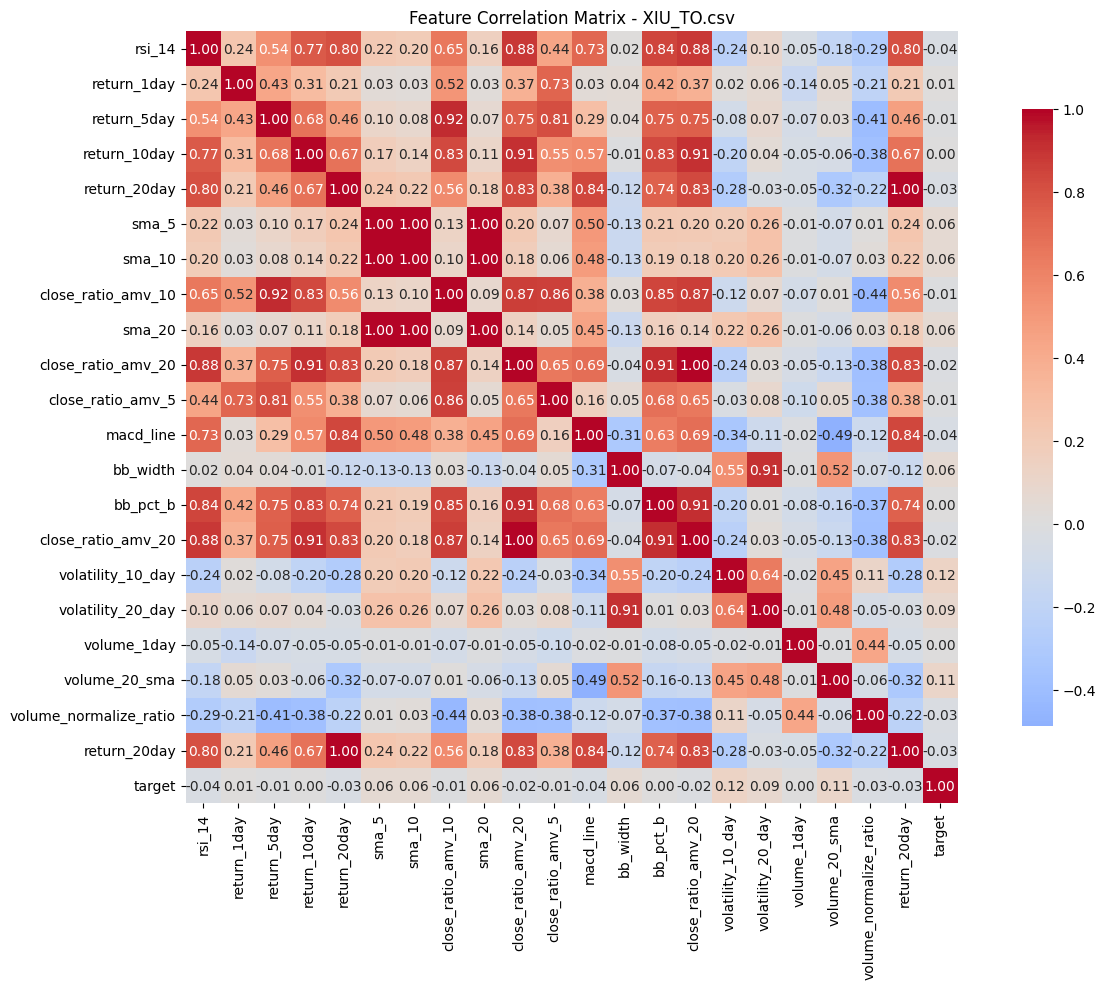

Feature correlations with target (|sorted|):
volatility_10_day         0.124649
volume_20_sma             0.109875
volatility_20_day         0.087755
sma_20                    0.061000
bb_width                  0.060936
sma_10                    0.059193
sma_5                     0.058380
macd_line                -0.042719
rsi_14                   -0.037077
return_20day             -0.031301
return_20day             -0.031301
volume_normalize_ratio   -0.026861
close_ratio_amv_20       -0.020407
close_ratio_amv_20       -0.020407
return_5day              -0.014318
return_1day               0.014025
close_ratio_amv_10       -0.012563
close_ratio_amv_5        -0.008384
return_10day              0.003582
bb_pct_b                  0.002206
volume_1day               0.001252
Feature correlations with future return (|sorted|):
volatility_10_day         0.124649
volume_20_sma             0.109875
volatility_20_day         0.087755
sma_20                    0.061000
bb_width                  0.

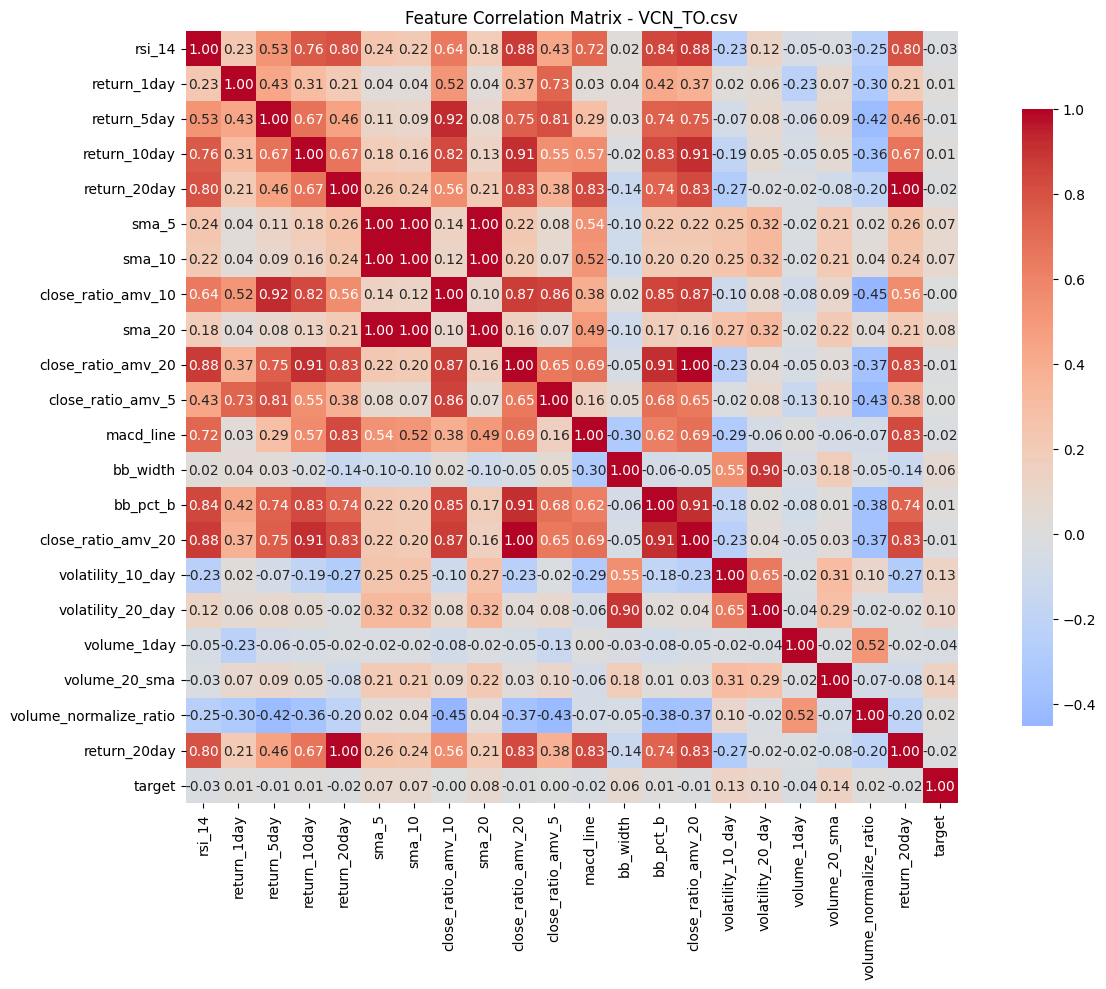

Feature correlations with target (|sorted|):
volume_20_sma             0.143513
volatility_10_day         0.130493
volatility_20_day         0.096273
sma_20                    0.076280
sma_10                    0.074582
sma_5                     0.073863
bb_width                  0.064225
volume_1day              -0.039963
rsi_14                   -0.026452
macd_line                -0.023670
return_20day             -0.015203
return_20day             -0.015203
volume_normalize_ratio    0.015065
bb_pct_b                  0.013123
return_1day               0.012351
close_ratio_amv_20       -0.011647
close_ratio_amv_20       -0.011647
return_10day              0.011037
return_5day              -0.006942
close_ratio_amv_10       -0.003171
close_ratio_amv_5         0.000401
Feature correlations with future return (|sorted|):
volume_20_sma             0.143513
volatility_10_day         0.130493
volatility_20_day         0.096273
sma_20                    0.076280
sma_10                    0.

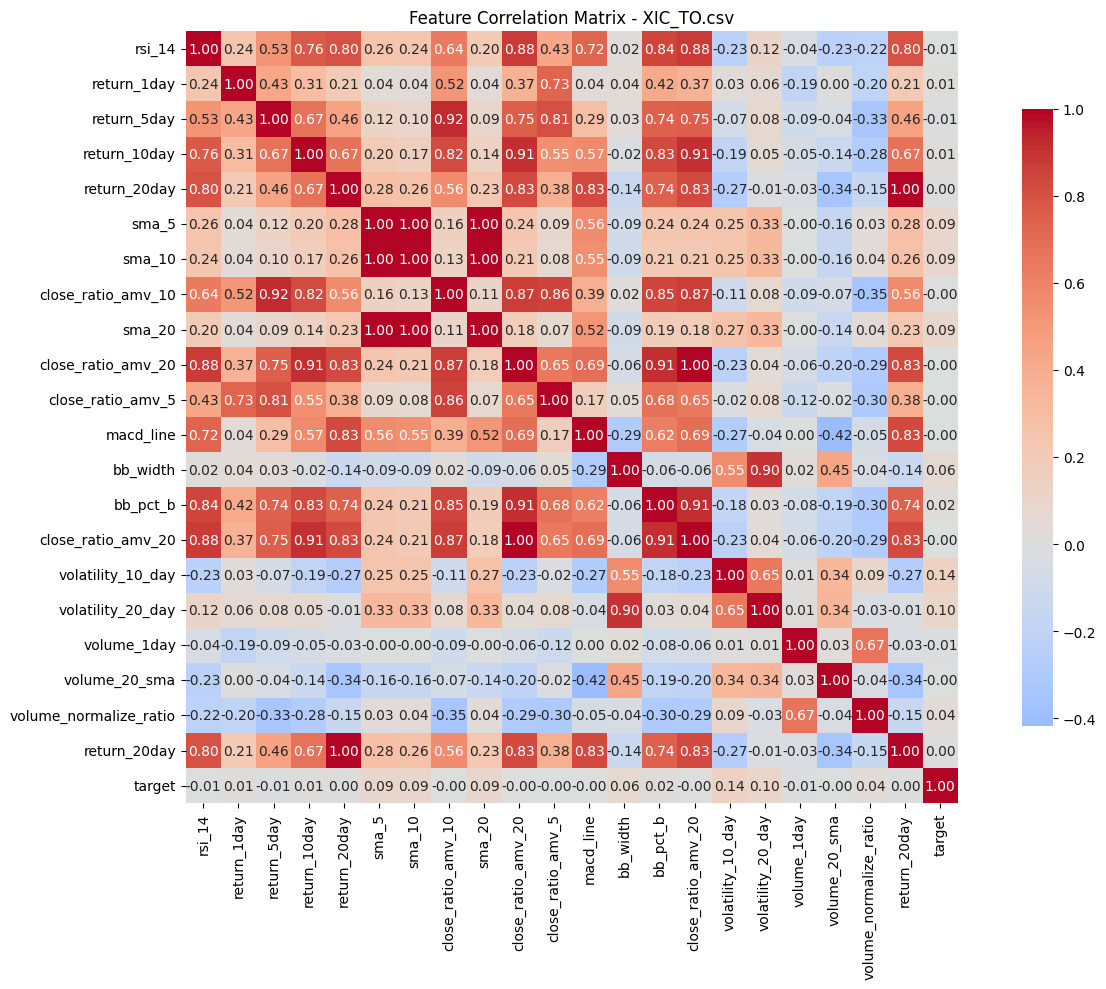

Feature correlations with target (|sorted|):
volatility_10_day         0.136629
volatility_20_day         0.103073
sma_20                    0.092434
sma_10                    0.091364
sma_5                     0.090579
bb_width                  0.064421
volume_normalize_ratio    0.040252
bb_pct_b                  0.021464
return_1day               0.013509
return_10day              0.012461
volume_1day              -0.008768
return_5day              -0.008094
rsi_14                   -0.007136
close_ratio_amv_10       -0.004610
return_20day              0.003367
return_20day              0.003367
close_ratio_amv_20       -0.002388
close_ratio_amv_20       -0.002388
close_ratio_amv_5        -0.001843
volume_20_sma            -0.000911
macd_line                -0.000297
Feature correlations with future return (|sorted|):
volatility_10_day         0.136629
volatility_20_day         0.103073
sma_20                    0.092434
sma_10                    0.091364
sma_5                     0.

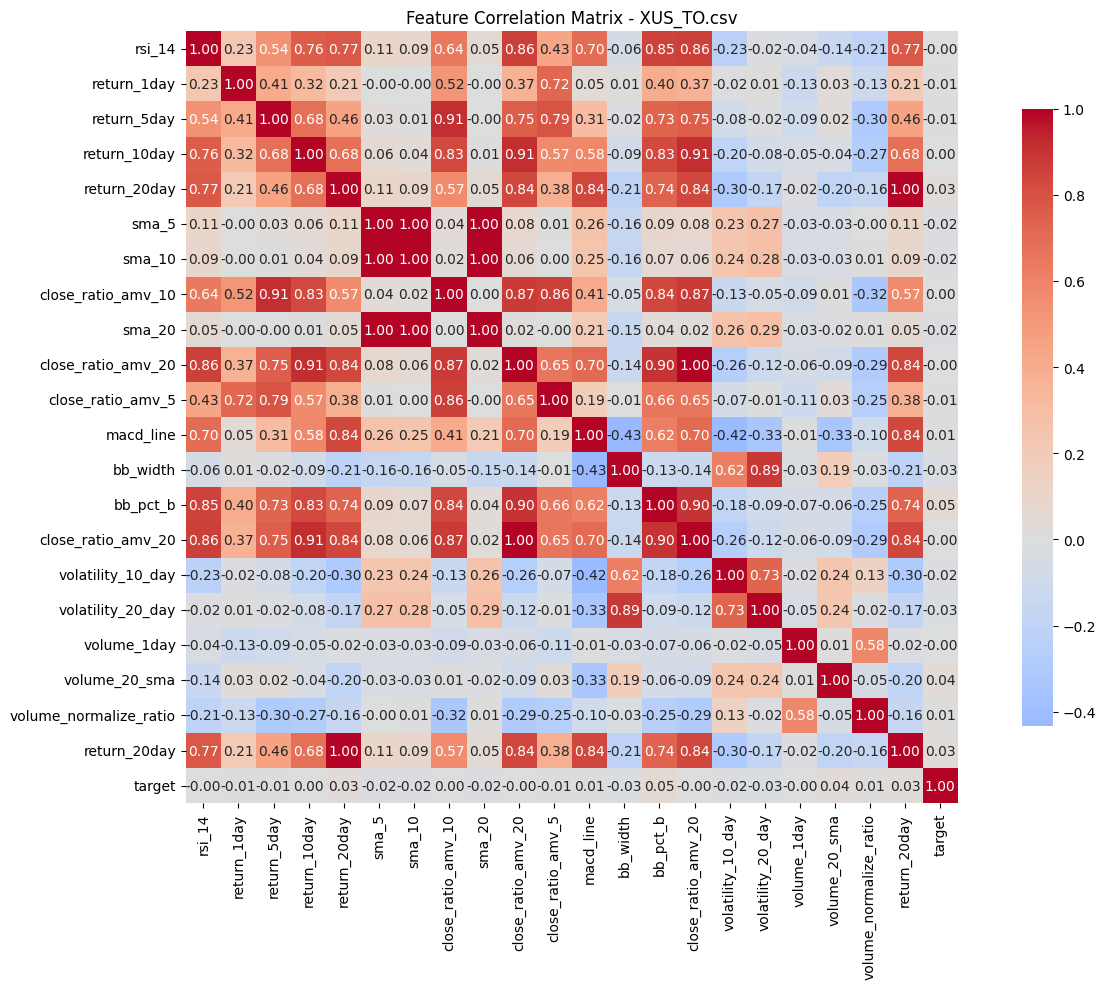

Feature correlations with target (|sorted|):
bb_pct_b                  0.052824
volume_20_sma             0.038612
bb_width                 -0.029508
return_20day              0.028413
return_20day              0.028413
volatility_20_day        -0.026687
volatility_10_day        -0.023920
sma_10                   -0.021353
sma_5                    -0.021261
sma_20                   -0.021223
macd_line                 0.012518
close_ratio_amv_5        -0.010556
volume_normalize_ratio    0.009820
return_1day              -0.009442
return_5day              -0.007746
return_10day              0.003057
rsi_14                   -0.002901
close_ratio_amv_10        0.001979
volume_1day              -0.000679
close_ratio_amv_20       -0.000092
close_ratio_amv_20       -0.000092
Feature correlations with future return (|sorted|):
bb_pct_b                  0.052824
volume_20_sma             0.038612
bb_width                 -0.029508
return_20day              0.028413
return_20day              0.

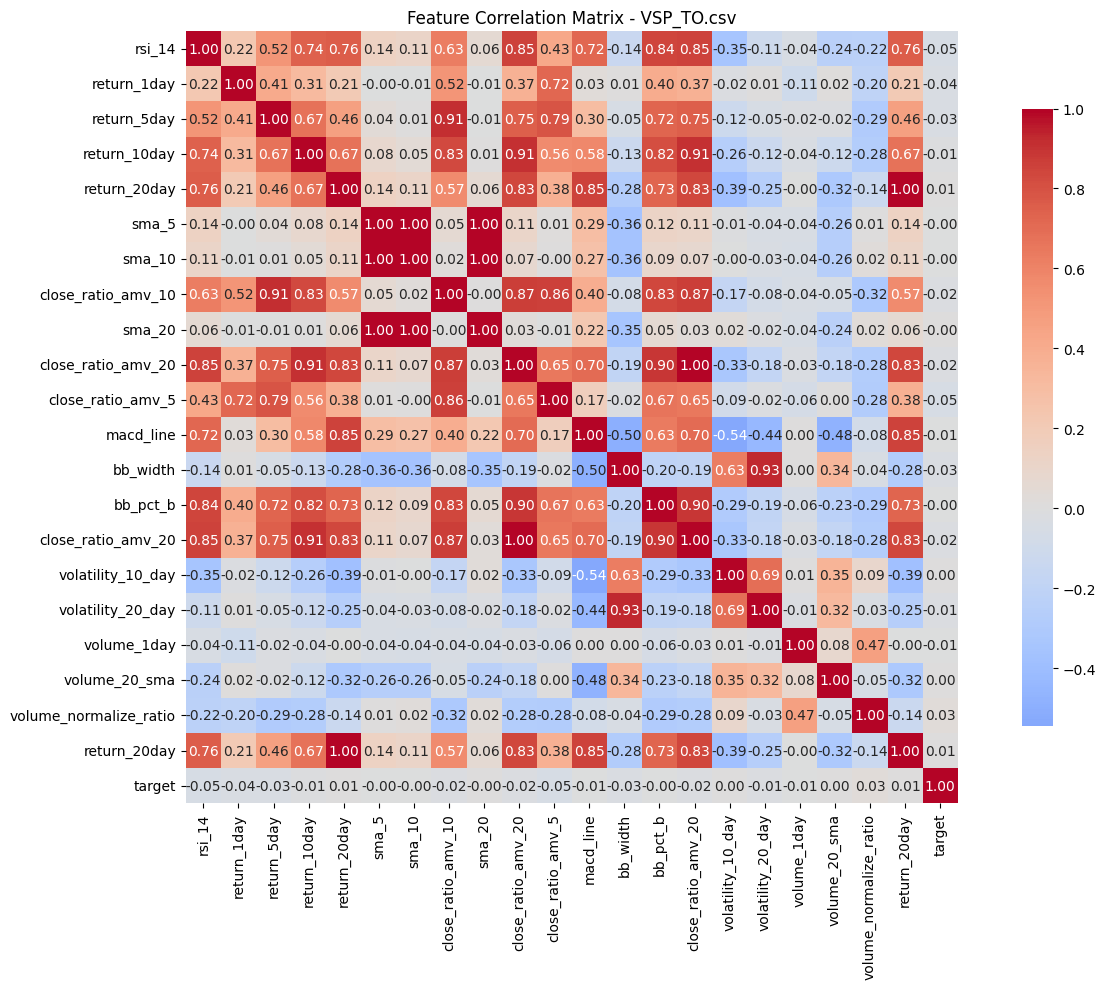

Feature correlations with target (|sorted|):
close_ratio_amv_5        -0.050345
rsi_14                   -0.048788
return_1day              -0.036586
volume_normalize_ratio    0.034293
return_5day              -0.033716
bb_width                 -0.026791
close_ratio_amv_10       -0.024771
close_ratio_amv_20       -0.022714
close_ratio_amv_20       -0.022714
volatility_20_day        -0.014959
return_20day              0.010032
return_20day              0.010032
return_10day             -0.007891
volume_1day              -0.006522
macd_line                -0.006080
volume_20_sma             0.004866
bb_pct_b                 -0.002855
volatility_10_day         0.002530
sma_10                   -0.001793
sma_5                    -0.001577
sma_20                   -0.000913
Feature correlations with future return (|sorted|):
close_ratio_amv_5        -0.050345
rsi_14                   -0.048788
return_1day              -0.036586
volume_normalize_ratio    0.034293
return_5day              -0.

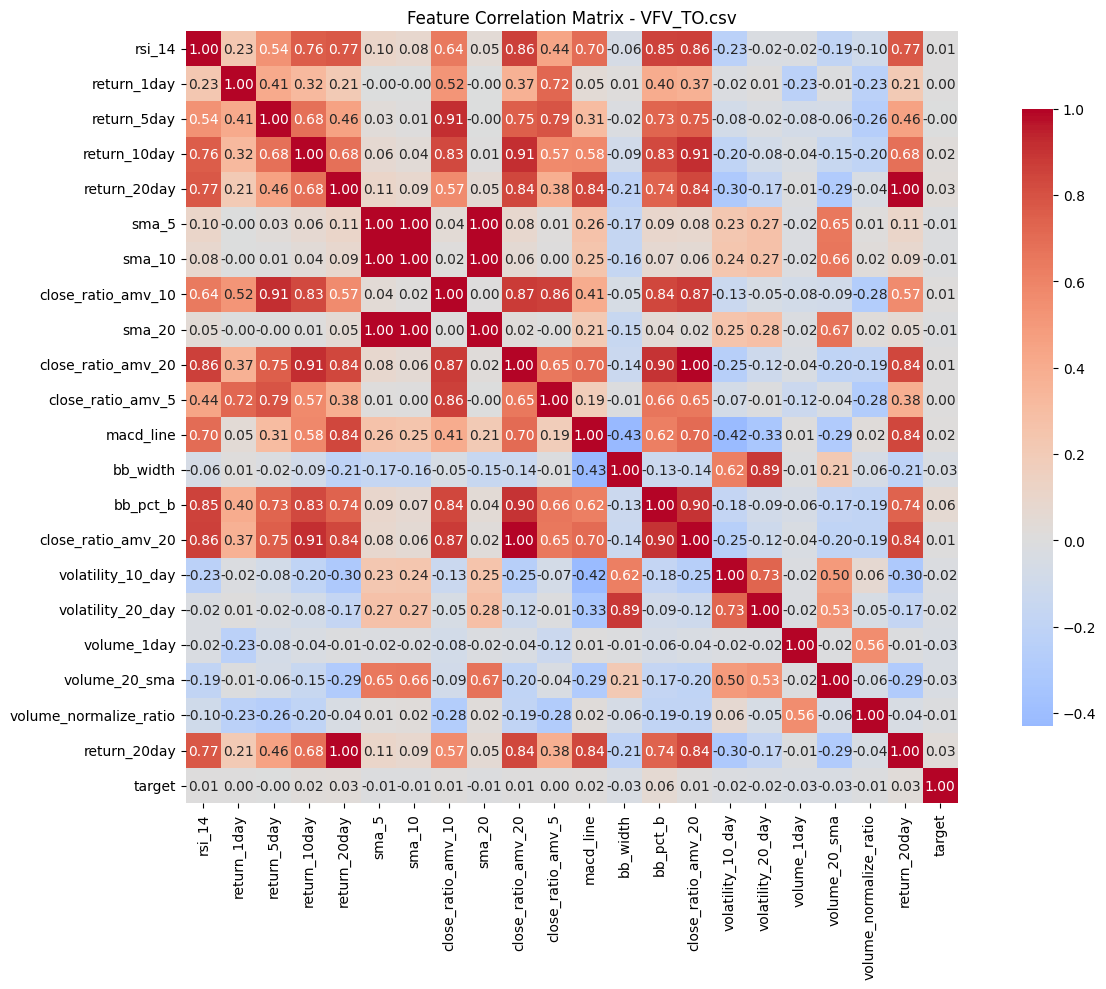

Feature correlations with target (|sorted|):
bb_pct_b                  0.058292
volume_20_sma            -0.032233
bb_width                 -0.031464
return_20day              0.031127
return_20day              0.031127
volume_1day              -0.028829
volatility_20_day        -0.023076
volatility_10_day        -0.020682
return_10day              0.017531
macd_line                 0.015111
sma_10                   -0.012691
sma_20                   -0.012618
sma_5                    -0.012461
close_ratio_amv_10        0.012281
volume_normalize_ratio   -0.009510
close_ratio_amv_20        0.008640
close_ratio_amv_20        0.008640
rsi_14                    0.005808
return_5day              -0.003558
close_ratio_amv_5         0.000588
return_1day               0.000488
Feature correlations with future return (|sorted|):
bb_pct_b                  0.058292
volume_20_sma            -0.032233
bb_width                 -0.031464
return_20day              0.031127
return_20day              0.

In [86]:
for stock, dataframe in data.items():
    figure, axis = plt.subplots(figsize=(14, 10))
    corr = dataframe[FEATURE_COLS + ["target"]].corr()

    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, ax=axis, cbar_kws={"shrink": 0.8})
    axis.set_title(f"Feature Correlation Matrix - {stock}")
    plt.tight_layout()
    plt.show()
    #get target
    target_corr = corr["target"].drop("target").sort_values(key=abs, ascending=False)
    #get future_return
    future_return_corr = corr["target"].drop("target").sort_values(key=abs, ascending=False)
    print("Feature correlations with target (|sorted|):")
    print(target_corr.to_string())
    print("Feature correlations with future return (|sorted|):")
    print(future_return_corr.to_string())

Correlation of Features to the Y-Variables:
                          target  future_return
bb_pct_b                0.058292       0.011533
return_20day            0.031127      -0.009305
return_20day            0.031127      -0.009305
return_20day            0.031127      -0.009305
return_20day            0.031127      -0.009305
return_10day            0.017531      -0.032402
macd_line               0.015111      -0.031799
close_ratio_amv_10      0.012281      -0.054537
close_ratio_amv_20      0.008640      -0.059197
close_ratio_amv_20      0.008640      -0.059197
close_ratio_amv_20      0.008640      -0.059197
close_ratio_amv_20      0.008640      -0.059197
rsi_14                  0.005808      -0.038727
close_ratio_amv_5       0.000588      -0.083255
return_1day             0.000488      -0.055862
return_5day            -0.003558      -0.054684
volume_normalize_ratio -0.009510       0.029224
sma_5                  -0.012461      -0.010117
sma_20                 -0.012618      -0.008

In [87]:
#Save files
DATA_DIR = os.path.join(os.getcwd(), "data")
os.makedirs(DATA_DIR, exist_ok=True)
for ticker, df in data.items():
    filename = os.path.join(DATA_DIR, f"{ticker.replace('.', '_')}.csv")
    df.to_csv(filename)
    print(f"Saved {filename} ({len(data[ticker])} rows)")

print("\nDone! Data is ready for notebook 03.")

Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/XIU_TO_csv.csv (1235 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/VCN_TO_csv.csv (1235 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/XIC_TO_csv.csv (1235 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/XUS_TO_csv.csv (1235 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/VSP_TO_csv.csv (1235 rows)
Saved /Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/notebooks/data/VFV_TO_csv.csv (1235 rows)

Done! Data is ready for notebook 03.
